In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import numpy as np

In [ ]:
df = pd.read_csv("D:\\Data Sets☠️💀\\Teen_Mental_Health_Dataset.csv")

In [ ]:
df.head()

In [ ]:
df.isna().sum()

In [ ]:
df.platform_usage.value_counts()

In [ ]:
df.social_interaction_level.value_counts()

In [ ]:
df.columns

In [ ]:
q1 = df.quantile(0.25,numeric_only=True)
q3 = df.quantile(0.75,numeric_only=True)
iqr = q3 - q1

upper_bound = q3 + 1.5 * iqr
lower_bound = q1 - 1.5 * iqr

In [ ]:
numerical_df = df.select_dtypes(include=['int','float'])

In [ ]:
outlier_rows = df[((numerical_df < lower_bound) | (numerical_df > upper_bound)).any(axis=1)]

outlier_rows

In [ ]:
x = df.drop('sleep_hours',axis=1)
y = df['sleep_hours']

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression,SGDRegressor
from sklearn.preprocessing import OneHotEncoder,OrdinalEncoder,StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import Lasso,Ridge
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
from xgboost import XGBRFRegressor
import optuna

In [ ]:
x_train,x_test,y_train,y_test = train_test_split(x,y,random_state=42,shuffle=True,test_size=0.2)

In [ ]:
df.columns
print(df.info())

In [ ]:
ohe_cols = ['gender','platform_usage']
ordinal_encode = ['social_interaction_level']
numerical_col = x_train.select_dtypes(include=['int','float']).columns

In [ ]:
df['social_interaction_level']

In [ ]:
print(ohe_cols)
print(ordinal_encode)
print(numerical_col)

In [138]:
from sklearn.linear_model import SGDRegressor
numerical_pipe = Pipeline(steps=[
    ('scale',StandardScaler())
])

ohe_pipe = Pipeline(steps=[
    ('ohe',OneHotEncoder(drop='first',handle_unknown='ignore'))
])

ordinal_pipe = Pipeline(steps=[
    ('ordinal',OrdinalEncoder(categories=[['high','medium','low']]))
])

column_trans = ColumnTransformer(transformers=[
    ('num',numerical_pipe,numerical_col),
    ('hot',ohe_pipe,ohe_cols),
    ('ord',ordinal_pipe,ordinal_encode)
])

model_pipline = Pipeline(steps=[
    ('process',column_trans),
    ('model',SGDRegressor( penalty='l1',
 max_iter=905,
 alpha= 0.05359331639490784))
]
)

In [ ]:
column_trans.fit(x_train,y_train)

In [139]:
model_pipline.fit(x_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('process', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('hot', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [140]:
pred = model_pipline.predict(x_test)

print(f'r2score is {r2_score(y_test,pred)}')

r2score is 0.02995945509981046


In [141]:
residuls = y_test - pred

<Axes: ylabel='sleep_hours'>

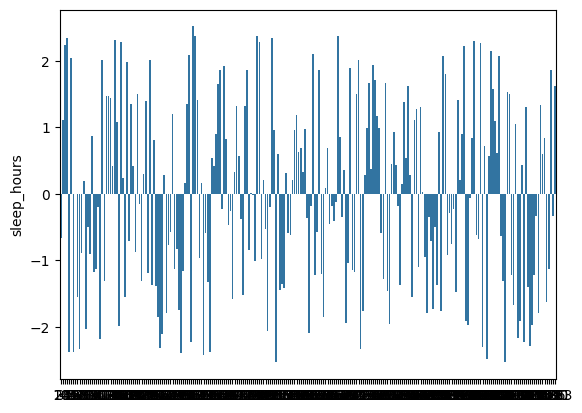

In [142]:
sns.barplot(residuls)

In [148]:
def objective(trail) -> 'hyper parameter':
    params = {'max_depth':trail.suggest_int('max_depth',4,20),
            'max_leaves':trail.suggest_int('max_leaves',3,6),
            'n_estimators':trail.suggest_int('n_estimators',8,30),
            'learning_rate':trail.suggest_float('learning_rate',1.5,5.5)}

    model = XGBRFRegressor(**params)

    model_pipe = Pipeline(steps=[
        ('process',column_trans),
        ('model',model)
    ])

    score = cross_val_score(model_pipe,x_train,y_train,scoring='r2').mean()
    return score


study = optuna.create_study(study_name='sachin veena🌻',direction='maximize')
study.optimize(objective,n_trials=30)

[I 2026-05-07 16:25:46,536] A new study created in memory with name: sachin veena🌻
[I 2026-05-07 16:25:47,218] Trial 0 finished with value: -0.03064232023715805 and parameters: {'max_depth': 17, 'max_leaves': 6, 'n_estimators': 10, 'learning_rate': 2.0315618798886406}. Best is trial 0 with value: -0.03064232023715805.
[I 2026-05-07 16:25:47,633] Trial 1 finished with value: -0.09007990608426134 and parameters: {'max_depth': 6, 'max_leaves': 3, 'n_estimators': 23, 'learning_rate': 2.8212607859215795}. Best is trial 0 with value: -0.03064232023715805.
[I 2026-05-07 16:25:48,055] Trial 2 finished with value: -0.20487867893599798 and parameters: {'max_depth': 16, 'max_leaves': 5, 'n_estimators': 10, 'learning_rate': 3.285448670221406}. Best is trial 0 with value: -0.03064232023715805.
[I 2026-05-07 16:25:48,605] Trial 3 finished with value: -0.14045339192034642 and parameters: {'max_depth': 8, 'max_leaves': 3, 'n_estimators': 26, 'learning_rate': 3.222681630295081}. Best is trial 0 with va

In [149]:
study.best_value

0.015715140589989927

In [150]:
study.best_params

{'max_depth': 11,
 'max_leaves': 3,
 'n_estimators': 20,
 'learning_rate': 1.509607086616515}

In [151]:
from optuna.visualization import plot_contour,plot_optimization_history,plot_parallel_coordinate,plot_param_importances

plot_optimization_history(study)

In [152]:
plot_contour(study)

In [153]:
plot_parallel_coordinate(study)

In [ ]:
study.trials_dataframe()

In [132]:
def obj_func(trial) -> 'hyper parameter':
    model_name = trial.suggest_categorical('model_name',['Lasso','Ridge','XGBRFRegressor','SGDRegressor'])

    if model_name == 'SGDRegressor':
        model = SGDRegressor(
            penalty=trial.suggest_categorical('penalty', ['l1', 'l2', 'elasticnet']),
            max_iter=trial.suggest_int('max_iter', 400, 1000),
            alpha=trial.suggest_float('alpha', 1e-5, 1e-1, log=True)
        )
    elif model_name == 'Lasso':
        model = Lasso(alpha=trial.suggest_float('alpha_lasso', 0.01, 10.0))
    elif model_name == 'Ridge':
        model = Ridge(alpha=trial.suggest_float('alpha_ridge', 0.01, 10.0))
    else:
        model = XGBRFRegressor(
            n_estimators=trial.suggest_int('n_estimators', 50, 200),
            max_depth=trial.suggest_int('max_depth', 3, 10)
        )

    final_pipeline = Pipeline(steps=[
        ('process',column_trans),
        ('model',model)
    ])

    score = cross_val_score(final_pipeline,x_train,y_train,scoring='r2',cv=5).mean()
    return score

In [133]:
study = optuna.create_study(study_name='sachinveena🌻',direction='maximize')
study.optimize(obj_func,n_trials=30)

[I 2026-05-07 13:37:40,811] A new study created in memory with name: sachinveena🌻
[I 2026-05-07 13:37:41,393] Trial 0 finished with value: 0.02076563255269399 and parameters: {'model_name': 'Ridge', 'alpha_ridge': 0.3856873087394853}. Best is trial 0 with value: 0.02076563255269399.
[I 2026-05-07 13:37:43,084] Trial 1 finished with value: 0.018843406428716312 and parameters: {'model_name': 'XGBRFRegressor', 'n_estimators': 133, 'max_depth': 4}. Best is trial 0 with value: 0.02076563255269399.
[I 2026-05-07 13:37:43,664] Trial 2 finished with value: -0.0052383382266819375 and parameters: {'model_name': 'Lasso', 'alpha_lasso': 9.580260454085815}. Best is trial 0 with value: 0.02076563255269399.
[I 2026-05-07 13:37:44,114] Trial 3 finished with value: 0.0210572726690756 and parameters: {'model_name': 'Ridge', 'alpha_ridge': 3.7315344722890655}. Best is trial 3 with value: 0.0210572726690756.
[I 2026-05-07 13:37:44,650] Trial 4 finished with value: -0.0052383382266819375 and parameters: {'

In [134]:
study.best_value

0.029822751562169847

In [136]:
study.best_params

{'model_name': 'SGDRegressor',
 'penalty': 'l1',
 'max_iter': 905,
 'alpha': 0.05359331639490784}

In [137]:
study.best_trials

[FrozenTrial(number=10, state=<TrialState.COMPLETE: 1>, values=[0.029822751562169847], datetime_start=datetime.datetime(2026, 5, 7, 13, 37, 47, 272901), datetime_complete=datetime.datetime(2026, 5, 7, 13, 37, 47, 938201), params={'model_name': 'SGDRegressor', 'penalty': 'l1', 'max_iter': 905, 'alpha': 0.05359331639490784}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={'model_name': CategoricalDistribution(choices=('Lasso', 'Ridge', 'XGBRFRegressor', 'SGDRegressor')), 'penalty': CategoricalDistribution(choices=('l1', 'l2', 'elasticnet')), 'max_iter': IntDistribution(high=1000, log=False, low=400, step=1), 'alpha': FloatDistribution(high=0.1, log=True, low=1e-05, step=None)}, trial_id=10, value=None)]

In [ ]:
def obj_func(trial):

    model_name = trial.suggest_categorical(
        'model_name',
        ['Lasso','Ridge','XGBRFRegressor']
    )

    # LINEAR MODELS
    if model_name in ['Lasso','Ridge']:

        preprocess = ColumnTransformer([
            ('num',StandardScaler(),numerical_col),
            ('cat',OneHotEncoder(),ohe_cols)
        ])

        if model_name == 'Lasso':
            model = Lasso(
                alpha=trial.suggest_float(
                    'alpha_lasso',
                    0.01,
                    10.0
                )
            )

        else:
            model = Ridge(
                alpha=trial.suggest_float(
                    'alpha_ridge',
                    0.01,
                    10.0
                )
            )

    # TREE MODEL
    else:

        preprocess = ColumnTransformer([
            ('num','passthrough',numerical_col),
            ('cat',OneHotEncoder(),ohe_cols)
        ])

        model = XGBRFRegressor(
            n_estimators=trial.suggest_int(
                'n_estimators',
                50,
                200
            ),

            max_depth=trial.suggest_int(
                'max_depth',
                3,
                10
            )
        )

    pipeline = Pipeline([
        ('process',preprocess),
        ('model',model)
    ])

    score = cross_val_score(
        pipeline,
        x_train,
        y_train,
        scoring='r2',
        cv=5
    ).mean()

    return score